In [1]:
import os
import pynvml
import tensorflow as tf

def get_most_free_gpu():
    pynvml.nvmlInit()
    device_count = pynvml.nvmlDeviceGetCount()

    max_free_mem = 0
    selected_gpu = 0
    for i in range(device_count):
        handle = pynvml.nvmlDeviceGetHandleByIndex(i)
        mem_info = pynvml.nvmlDeviceGetMemoryInfo(handle)
        free_mem = mem_info.free
        print(f"GPU {i}: Free Memory = {free_mem // 1024**2} MB")
        if free_mem > max_free_mem:
            max_free_mem = free_mem
            selected_gpu = i

    pynvml.nvmlShutdown()
    print(f"\n✅ TensorFlow will use GPU {selected_gpu} with {max_free_mem // 1024**2} MB free memory.\n")
    return selected_gpu

# Set TensorFlow to use the most free GPU
gpu_id = get_most_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_id)

# (Optional) Confirm in TensorFlow
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        tf.config.experimental.set_visible_devices(gpus[0], "GPU")
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"TensorFlow is set to use: {gpus[0]}")
    except RuntimeError as e:
        print(e)

2026-04-20 12:05:46.169717: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 12:05:46.322275: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 12:05:47.782539: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


GPU 0: Free Memory = 1887 MB
GPU 1: Free Memory = 46607 MB
GPU 2: Free Memory = 45631 MB
GPU 3: Free Memory = 56193 MB
GPU 4: Free Memory = 34759 MB
GPU 5: Free Memory = 20751 MB
GPU 6: Free Memory = 51539 MB
GPU 7: Free Memory = 26409 MB

✅ TensorFlow will use GPU 3 with 56193 MB free memory.

TensorFlow is set to use: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')



CREATING UTKFACE DATA GENERATORS
Class mapping: ['White', 'Black', 'Asian', 'Indian']

📂 Loading TRAINING data (90%):
Found 15847 images belonging to 4 classes.
✅ Generator created for /home/kunj.bihari/Priyanka/mobile__utkface/UTKFace_split_80_10_20/Train
   Classes: {'White': 0, 'Black': 1, 'Asian': 2, 'Indian': 3}
   Samples: 15847

📂 Loading VALIDATION data (10%):
Found 1762 images belonging to 4 classes.
✅ Generator created for /home/kunj.bihari/Priyanka/mobile__utkface/UTKFace_split_80_10_20/Val
   Classes: {'White': 0, 'Black': 1, 'Asian': 2, 'Indian': 3}
   Samples: 1762

📂 Loading TEST data (20%):
Found 4404 images belonging to 4 classes.
✅ Generator created for /home/kunj.bihari/Priyanka/mobile__utkface/UTKFace_split_80_10_20/Test
   Classes: {'White': 0, 'Black': 1, 'Asian': 2, 'Indian': 3}
   Samples: 4404

CLASS DISTRIBUTION

📊 TRAINING (90%) Set:
--------------------------------------------------
  White: 7255 images (45.78%)
  Black: 3258 images (20.56%)
  Asian: 2472 i

2026-04-20 12:06:15.137897: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 54085 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:5f:00.0, compute capability: 8.0



📊 Base Model:
   Layers: 263
   Parameters: 2,996,352

MODIFIED BLOCK-WISE FREEZING STRATEGY

📋 Block Structure:
   expanded_conv        → layers   8-262 (255 layers)

🔒 MODIFIED Freezing Strategy:
   Total blocks: 15
   Frozen blocks (first 11): ['expanded_conv', 'expanded_conv_1', 'expanded_conv_2', 'expanded_conv_3', 'expanded_conv_4', 'expanded_conv_5', 'expanded_conv_6', 'expanded_conv_7', 'expanded_conv_8', 'expanded_conv_9', 'expanded_conv_10']
   Trainable blocks (last 4): ['expanded_conv_11', 'expanded_conv_12', 'expanded_conv_13', 'expanded_conv_14']

📊 Layer Freezing Stats:
   Frozen layers: 142
   Trainable layers: 121
   Total base layers: 263

✅ Verification - Trainable blocks (last 4):
   expanded_conv_11/expand: trainable = False
   expanded_conv_11/expand/BatchNorm: trainable = False
   expanded_conv_11/depthwise: trainable = False
   expanded_conv_11/depthwise/BatchNorm: trainable = False
   expanded_conv_11/squeeze_excite/AvgPool: trainable = False
   expanded_conv_

2026-04-20 12:06:21.866435: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8906
2026-04-20 12:06:29.157381: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-04-20 12:06:29.220078: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x30e14ee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-20 12:06:29.220108: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB, Compute Capability 8.0
2026-04-20 12:06:29.288168: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


496/496 [==============================] - ETA: 0s - loss: 1.2391 - accuracy: 0.5104
Epoch 1: val_accuracy improved from -inf to 0.60783, saving model to mobilenetv3_utkface_best_phase1.h5
496/496 [==============================] - 133s 235ms/step - loss: 1.2391 - accuracy: 0.5104 - val_loss: 0.9764 - val_accuracy: 0.6078 - lr: 0.0010
Epoch 2/100
496/496 [==============================] - ETA: 0s - loss: 0.9477 - accuracy: 0.6190
Epoch 2: val_accuracy improved from 0.60783 to 0.63905, saving model to mobilenetv3_utkface_best_phase1.h5
496/496 [==============================] - 125s 251ms/step - loss: 0.9477 - accuracy: 0.6190 - val_loss: 0.9178 - val_accuracy: 0.6390 - lr: 0.0010
Epoch 3/100
496/496 [==============================] - ETA: 0s - loss: 0.8492 - accuracy: 0.6579
Epoch 3: val_accuracy improved from 0.63905 to 0.68048, saving model to mobilenetv3_utkface_best_phase1.h5
496/496 [==============================] - 125s 251ms/step - loss: 0.8492 - accuracy: 0.6579 - val_loss: 0.

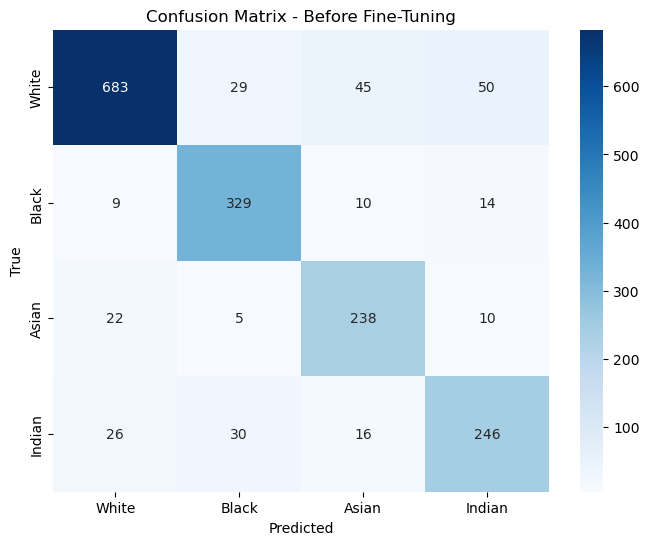


🎯 Balanced Accuracy: 0.8486


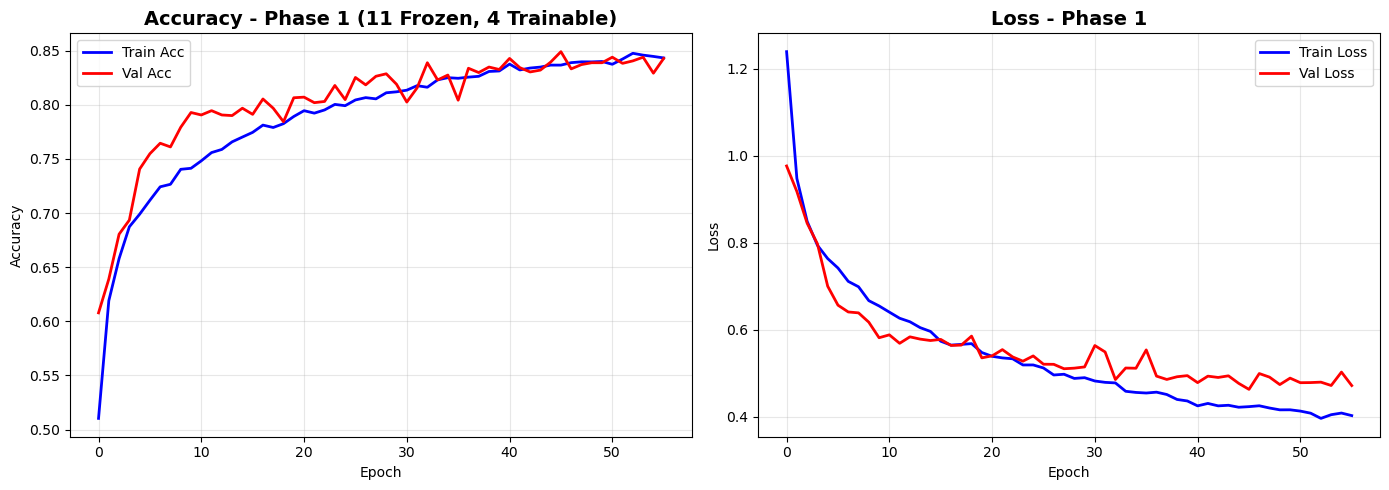

✅ Phase 1 plot saved

🧠 FINE-TUNING PHASE (Unfreezing ALL Layers)

📊 Trainable params before: 715,476
📊 Trainable params after:  3,531,444
📊 Newly trainable: 2,815,968

✅ Verification - All layers now trainable:
   Total trainable layers: 271

✅ Recompiled with lr=1e-4
Epoch 1/30
496/496 [==============================] - ETA: 0s - loss: 0.9366 - accuracy: 0.6768
Epoch 1: val_accuracy did not improve from 0.84904
496/496 [==============================] - 141s 251ms/step - loss: 0.9366 - accuracy: 0.6768 - val_loss: 0.5971 - val_accuracy: 0.8065 - lr: 1.0000e-04
Epoch 2/30
496/496 [==============================] - ETA: 0s - loss: 0.7277 - accuracy: 0.7251
Epoch 2: val_accuracy did not improve from 0.84904
496/496 [==============================] - 134s 269ms/step - loss: 0.7277 - accuracy: 0.7251 - val_loss: 0.5749 - val_accuracy: 0.7951 - lr: 1.0000e-04
Epoch 3/30
496/496 [==============================] - ETA: 0s - loss: 0.6676 - accuracy: 0.7482
Epoch 3: val_accuracy did not improv

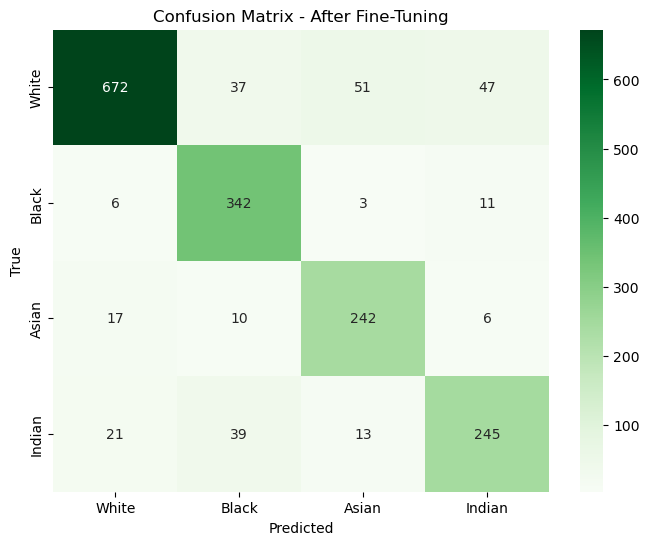


🎯 TEST ON UNSEEN TEST SET (20% Data)
138/138 [==============================] - 14s 105ms/step

📊 Test Classification Report:
              precision    recall  f1-score   support

       White     0.9461    0.8532    0.8972      2016
       Black     0.8186    0.9316    0.8715       906
       Asian     0.7913    0.9214    0.8514       687
      Indian     0.8159    0.7748    0.7948       795

    accuracy                         0.8658      4404
   macro avg     0.8430    0.8702    0.8537      4404
weighted avg     0.8722    0.8658    0.8663      4404


📊 Test Metrics:
   Standard Accuracy: 0.8658 (86.58%)
   Balanced Accuracy: 0.8702 (87.02%)

📊 Per-Class Accuracy:
   White: 0.8532 (85.32%)
   Black: 0.9316 (93.16%)
   Asian: 0.9214 (92.14%)
   Indian: 0.7748 (77.48%)

📊 Disparity: 0.1567


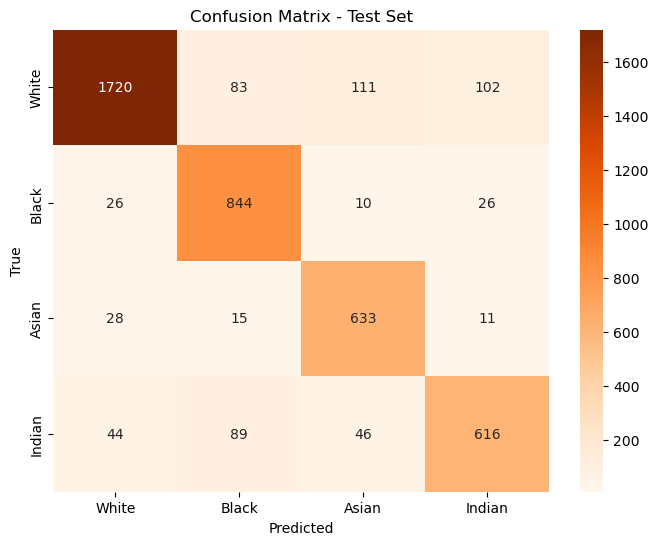

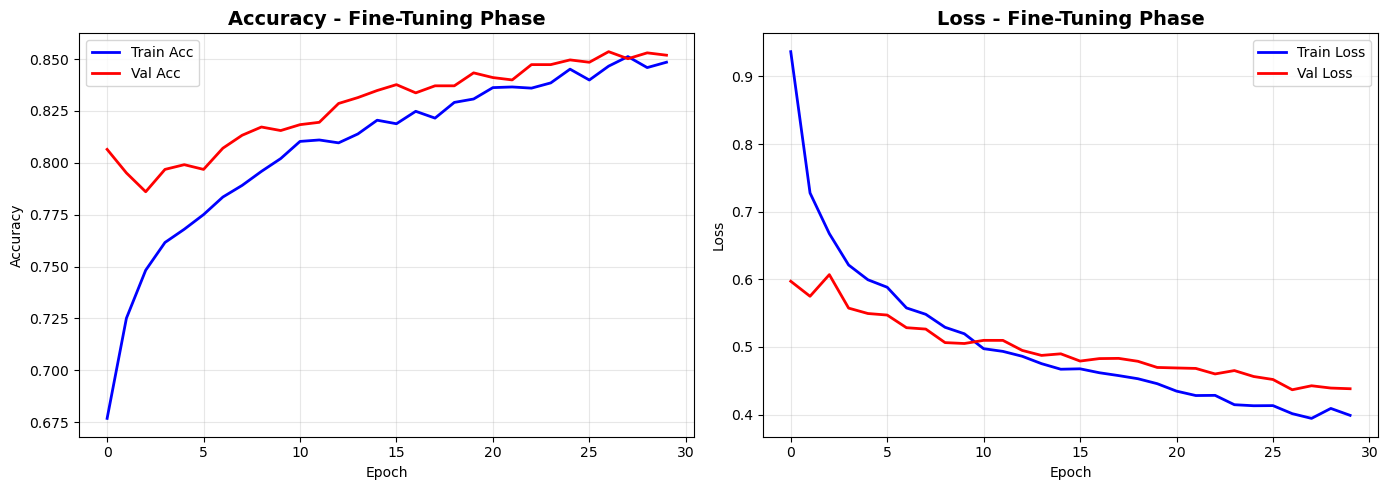

✅ Fine-tuning plot saved

✅ Final model saved: mobilenetv3_utkface_final.h5
✅ Weights saved: mobilenetv3_utkface_weights.h5
✅ Summary saved: utkface_model_summary.txt
✅ Architecture saved: utkface_model_architecture.txt

📋 FINAL TRAINING SUMMARY
✅ Freezing (Phase 1): First 11 blocks frozen, Last 4 blocks trainable
✅ Freezing (Fine-Tune): ALL layers unfrozen
✅ Classes: ['White', 'Black', 'Asian', 'Indian']
✅ Test Accuracy: 0.8658 (86.58%)
✅ Test Balanced Accuracy: 0.8702 (87.02%)
✅ Test Disparity: 0.1567

📁 Generated Files:
   1. mobilenetv3_utkface_best_phase1.h5 - Best Phase 1 model
   2. mobilenetv3_utkface_final.h5 - Final model (SINGLE FILE)
   3. mobilenetv3_utkface_weights.h5 - Weights only
   4. utkface_training_history_phase1.png - Phase 1 curves
   5. utkface_training_history_finetune.png - Fine-tuning curves
   6. utkface_training_log.csv - Training log
   7. utkface_model_summary.txt - Summary
   8. utkface_model_architecture.txt - Architecture

🔮 Usage:

from tensorflow.ker

In [2]:
"""
MobileNetV3Large for Race Classification on UTKFace Dataset
Classes: White, Black, Asian, Indian
Split: 90% Train, 10% Validation, 20% Test
Freezing Strategy: First 11 blocks frozen, Last 4 blocks trainable (Phase 1)
Fine-Tuning: All layers unfrozen
"""

# ============================================
# STEP 1: Imports
# ============================================
import os
import sys
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings("ignore")

# ============================================
# STEP 2: Paths (UTKFace Dataset)
# ============================================
UTK_TRAIN_DIR = "/home/kunj.bihari/Priyanka/mobile__utkface/UTKFace_split_80_10_20/Train"
UTK_VAL_DIR   = "/home/kunj.bihari/Priyanka/mobile__utkface/UTKFace_split_80_10_20/Val"
UTK_TEST_DIR  = "/home/kunj.bihari/Priyanka/mobile__utkface/UTKFace_split_80_10_20/Test"

# ============================================
# STEP 2.5: Define Class Mapping
# ============================================
CLASS_NAMES = ['White', 'Black', 'Asian', 'Indian']
CLASS_INDICES = {
    'White': 0,
    'Black': 1,
    'Asian': 2,
    'Indian': 3
}

# ============================================
# STEP 3: Data Generator
# ============================================
def create_utkface_generator(directory, target_size, batch_size, is_training=True):
    existing_folders = [f for f in CLASS_NAMES if os.path.isdir(os.path.join(directory, f))]
    missing_folders = [f for f in CLASS_NAMES if f not in existing_folders]
    
    if missing_folders:
        print(f"⚠️ Warning: Missing classes in {directory}: {missing_folders}")
    
    if not existing_folders:
        print(f"❌ ERROR: No class folders found in {directory}")
        return None
    
    if is_training:
        datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            brightness_range=[0.8, 1.2],
            fill_mode='nearest'
        )
    else:
        datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
    
    generator = datagen.flow_from_directory(
        directory,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical',
        classes=existing_folders,
        shuffle=is_training
    )
    
    print(f"✅ Generator created for {directory}")
    print(f"   Classes: {generator.class_indices}")
    print(f"   Samples: {generator.samples}")
    return generator

# ============================================
# STEP 3.5: Create Generators
# ============================================
print("\n" + "="*70)
print("CREATING UTKFACE DATA GENERATORS")
print("="*70)
print(f"Class mapping: {CLASS_NAMES}")
print("="*70)

print("\n📂 Loading TRAINING data (90%):")
train_gen = create_utkface_generator(UTK_TRAIN_DIR, (224, 224), 32, is_training=True)

print("\n📂 Loading VALIDATION data (10%):")
val_gen = create_utkface_generator(UTK_VAL_DIR, (224, 224), 32, is_training=False)

print("\n📂 Loading TEST data (20%):")
test_gen = create_utkface_generator(UTK_TEST_DIR, (224, 224), 32, is_training=False)

if train_gen is None or val_gen is None or test_gen is None:
    print("\n❌ ERROR: Failed to create generators.")
    exit(1)

# ============================================
# STEP 3.6: Class Distribution
# ============================================
print("\n" + "="*70)
print("CLASS DISTRIBUTION")
print("="*70)

def print_class_distribution(generator, name):
    print(f"\n📊 {name} Set:")
    print("-" * 50)
    class_counts = np.bincount(generator.classes)
    total = len(generator.classes)
    for i, name in enumerate(CLASS_NAMES):
        count = class_counts[i] if i < len(class_counts) else 0
        pct = (count / total) * 100 if total > 0 else 0
        print(f"  {name}: {count} images ({pct:.2f}%)")
    print(f"\n  Total: {total}")

print_class_distribution(train_gen, "TRAINING (90%)")
print_class_distribution(val_gen, "VALIDATION (10%)")
print_class_distribution(test_gen, "TEST (20%)")

# ============================================
# STEP 3.7: Class Weights
# ============================================
print("\n" + "="*70)
print("CLASS WEIGHTS")
print("="*70)

class_counts_train = np.bincount(train_gen.classes)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))

print("\n⚖️ Class Weights:")
for i, class_name in enumerate(CLASS_NAMES):
    weight = class_weights[i] if i < len(class_weights) else 1.0
    print(f"  {class_name}: {weight:.4f} (samples: {class_counts_train[i]})")

# ============================================
# STEP 4: Build Model with MODIFIED FREEZING (11 blocks frozen, 4 blocks trainable)
# ============================================
print("\n" + "="*70)
print("BUILDING MODEL WITH MODIFIED BLOCK-WISE FREEZING")
print("="*70)

base_model = MobileNetV3Large(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

print(f"\n📊 Base Model:")
print(f"   Layers: {len(base_model.layers)}")
print(f"   Parameters: {base_model.count_params():,}")

# ============================================
# 🔥 MODIFIED: 11 BLOCKS FROZEN, 4 BLOCKS TRAINABLE 🔥
# ============================================
print("\n" + "="*70)
print("MODIFIED BLOCK-WISE FREEZING STRATEGY")
print("="*70)

block_names = ['expanded_conv'] + [f'expanded_conv_{i}' for i in range(1, 15)]

# Find block boundaries
block_boundaries = {}
current_block = None

for i, layer in enumerate(base_model.layers):
    layer_name = layer.name
    for block_name in block_names:
        if layer_name.startswith(block_name):
            if current_block != block_name:
                current_block = block_name
                block_boundaries[block_name] = {'start': i, 'end': None}
            break
    if current_block:
        block_boundaries[current_block]['end'] = i

print("\n📋 Block Structure:")
for block_name in block_names:
    if block_name in block_boundaries:
        start = block_boundaries[block_name]['start']
        end = block_boundaries[block_name]['end']
        num = end - start + 1
        print(f"   {block_name:<20} → layers {start:3d}-{end:3d} ({num:3d} layers)")

# 🔥 NEW: Freeze first 11 blocks, keep last 4 blocks trainable
blocks_to_freeze = 11   # First 11 blocks (expanded_conv to expanded_conv_10)
trainable_blocks = 4    # Last 4 blocks (expanded_conv_11, expanded_conv_12, expanded_conv_13, expanded_conv_14)

print(f"\n🔒 MODIFIED Freezing Strategy:")
print(f"   Total blocks: 15")
print(f"   Frozen blocks (first {blocks_to_freeze}): {block_names[:blocks_to_freeze]}")
print(f"   Trainable blocks (last {trainable_blocks}): {block_names[blocks_to_freeze:]}")

# Apply freezing
frozen_count = 0
trainable_count = 0

for layer in base_model.layers:
    layer_name = layer.name
    is_frozen = False
    
    for block_name in block_names[:blocks_to_freeze]:
        if layer_name.startswith(block_name):
            layer.trainable = False
            is_frozen = True
            frozen_count += 1
            break
    
    if not is_frozen:
        layer.trainable = True
        trainable_count += 1

print(f"\n📊 Layer Freezing Stats:")
print(f"   Frozen layers: {frozen_count}")
print(f"   Trainable layers: {trainable_count}")
print(f"   Total base layers: {len(base_model.layers)}")

# Verify trainable blocks
print(f"\n✅ Verification - Trainable blocks (last 4):")
for layer in base_model.layers:
    if (layer.name.startswith('expanded_conv_11') or 
        layer.name.startswith('expanded_conv_12') or 
        layer.name.startswith('expanded_conv_13') or 
        layer.name.startswith('expanded_conv_14')):
        print(f"   {layer.name}: trainable = {layer.trainable}")

# ============================================
# STEP 4.5: Custom Head (Always Trainable)
# ============================================
print("\n" + "="*70)
print("ADDING CUSTOM CLASSIFICATION HEAD")
print("="*70)

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu', name='dense_1')(x)
x = BatchNormalization(name='bn_1')(x)
x = Dropout(0.5, name='dropout_1')(x)
x = Dense(128, activation='relu', name='dense_2')(x)
x = BatchNormalization(name='bn_2')(x)
x = Dropout(0.3, name='dropout_2')(x)
output = Dense(4, activation='softmax', name='race_output')(x)

model = Model(inputs=base_model.input, outputs=output)

print(f"\n✅ Custom Head (always trainable):")
print(f"   GAP → Dense(512) → BN → Dropout(0.5) → Dense(128) → BN → Dropout(0.3) → Dense(4)")

# ============================================
# STEP 4.6: Model Summary
# ============================================
print("\n" + "="*70)
print("MODEL SUMMARY")
print("="*70)

model.summary()

total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable = total_params - trainable_params

print("\n" + "="*70)
print("MODEL STATISTICS")
print("="*70)
print(f"   Total parameters:      {total_params:,}")
print(f"   Trainable parameters:  {trainable_params:,}")
print(f"   Non-trainable:         {non_trainable:,}")
print(f"   Trainable ratio:       {(trainable_params/total_params)*100:.2f}%")
print(f"   Model size (FP32):     {total_params * 4 / (1024**2):.2f} MB")

# ============================================
# STEP 5: Compile Model
# ============================================
optimizer = SGD(learning_rate=1e-3, momentum=0.9, nesterov=True)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
print("\n✅ Model compiled with SGD (lr=1e-3)")

# ============================================
# STEP 6: Callbacks
# ============================================
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint("mobilenetv3_utkface_best_phase1.h5", monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1),
    CSVLogger('utkface_training_log.csv', append=False)
]

print("\n📋 Callbacks configured")

# ============================================
# STEP 7: Phase 1 Training (11 frozen, 4 trainable)
# ============================================
print("\n" + "="*70)
print("🚀 PHASE 1: 11 Blocks Frozen, 4 Blocks Trainable")
print("="*70)
print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Class mapping: {CLASS_NAMES}")
print(f"Class weights: {class_weight_dict}")
print(f"Epochs: 100 | Batch: 32")
print("="*70 + "\n")

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# ============================================
# STEP 8: Evaluation Before Fine-Tuning
# ============================================
print("\n" + "="*70)
print("🔍 EVALUATION (Before Fine-Tuning)")
print("="*70)

val_gen.reset()
val_preds = model.predict(val_gen, verbose=1)
val_y_pred = np.argmax(val_preds, axis=1)
val_y_true = val_gen.classes

print("\n📊 Classification Report:")
print(classification_report(val_y_true, val_y_pred, target_names=CLASS_NAMES, digits=4))

# Confusion Matrix
val_cm = confusion_matrix(val_y_true, val_y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Before Fine-Tuning')
plt.show()

val_balanced_acc = balanced_accuracy_score(val_y_true, val_y_pred)
print(f"\n🎯 Balanced Accuracy: {val_balanced_acc:.4f}")

# ============================================
# STEP 9: Phase 1 Training Curves
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], 'b-', label='Train Acc', linewidth=2)
axes[0].plot(history.history['val_accuracy'], 'r-', label='Val Acc', linewidth=2)
axes[0].set_title('Accuracy - Phase 1 (11 Frozen, 4 Trainable)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], 'b-', label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[1].set_title('Loss - Phase 1', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('utkface_training_history_phase1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Phase 1 plot saved")

# ============================================
# STEP 10: Fine-Tuning (Unfreeze ALL)
# ============================================
print("\n" + "="*70)
print("🧠 FINE-TUNING PHASE (Unfreezing ALL Layers)")
print("="*70)

trainable_before = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])

for layer in model.layers:
    layer.trainable = True

trainable_after = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])

print(f"\n📊 Trainable params before: {trainable_before:,}")
print(f"📊 Trainable params after:  {trainable_after:,}")
print(f"📊 Newly trainable: {trainable_after - trainable_before:,}")

# Verify all are trainable
print("\n✅ Verification - All layers now trainable:")
trainable_layers = sum([1 for layer in model.layers if layer.trainable])
print(f"   Total trainable layers: {trainable_layers}")

# Recompile with lower LR
optimizer_ft = SGD(learning_rate=1e-4, momentum=0.9, nesterov=True)
model.compile(optimizer=optimizer_ft, loss='categorical_crossentropy', metrics=['accuracy'])
print("\n✅ Recompiled with lr=1e-4")

# Fine-tune
fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# ============================================
# STEP 11: Final Validation Evaluation
# ============================================
print("\n" + "="*70)
print("✅ FINAL VALIDATION EVALUATION (After Fine-Tuning)")
print("="*70)

val_gen.reset()
final_val_preds = model.predict(val_gen, verbose=1)
final_val_y_pred = np.argmax(final_val_preds, axis=1)

print("\n📊 Classification Report:")
print(classification_report(val_y_true, final_val_y_pred, target_names=CLASS_NAMES, digits=4))

final_val_balanced = balanced_accuracy_score(val_y_true, final_val_y_pred)
print(f"\n🎯 Balanced Accuracy: {final_val_balanced:.4f}")

val_per_class = recall_score(val_y_true, final_val_y_pred, average=None)
print("\n📊 Per-Class Accuracy:")
for i, name in enumerate(CLASS_NAMES):
    print(f"   {name}: {val_per_class[i]:.4f} ({val_per_class[i]*100:.2f}%)")

val_disparity = np.max(val_per_class) - np.min(val_per_class)
print(f"\n📊 Disparity: {val_disparity:.4f}")

# Final confusion matrix
final_val_cm = confusion_matrix(val_y_true, final_val_y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(final_val_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - After Fine-Tuning')
plt.show()

# ============================================
# STEP 12: Test on Unseen Test Set
# ============================================
print("\n" + "="*70)
print("🎯 TEST ON UNSEEN TEST SET (20% Data)")
print("="*70)

test_gen.reset()
test_preds = model.predict(test_gen, verbose=1)
test_y_pred = np.argmax(test_preds, axis=1)
test_y_true = test_gen.classes

print("\n📊 Test Classification Report:")
print(classification_report(test_y_true, test_y_pred, target_names=CLASS_NAMES, digits=4))

test_acc = np.mean(test_y_pred == test_y_true)
test_balanced = balanced_accuracy_score(test_y_true, test_y_pred)

print(f"\n📊 Test Metrics:")
print(f"   Standard Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Balanced Accuracy: {test_balanced:.4f} ({test_balanced*100:.2f}%)")

test_per_class = recall_score(test_y_true, test_y_pred, average=None)
print("\n📊 Per-Class Accuracy:")
for i, name in enumerate(CLASS_NAMES):
    print(f"   {name}: {test_per_class[i]:.4f} ({test_per_class[i]*100:.2f}%)")

test_disparity = np.max(test_per_class) - np.min(test_per_class)
print(f"\n📊 Disparity: {test_disparity:.4f}")

# Test confusion matrix
test_cm = confusion_matrix(test_y_true, test_y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')
plt.show()

# ============================================
# STEP 13: Fine-Tuning Curves
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fine_tune_history.history['accuracy'], 'b-', label='Train Acc', linewidth=2)
axes[0].plot(fine_tune_history.history['val_accuracy'], 'r-', label='Val Acc', linewidth=2)
axes[0].set_title('Accuracy - Fine-Tuning Phase', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(fine_tune_history.history['loss'], 'b-', label='Train Loss', linewidth=2)
axes[1].plot(fine_tune_history.history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[1].set_title('Loss - Fine-Tuning Phase', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('utkface_training_history_finetune.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Fine-tuning plot saved")

# ============================================
# STEP 14: Save Final Model (Single File)
# ============================================
model.save("mobilenetv3_utkface_final.h5")
print("\n✅ Final model saved: mobilenetv3_utkface_final.h5")

model.save_weights("mobilenetv3_utkface_weights.h5")
print("✅ Weights saved: mobilenetv3_utkface_weights.h5")

# ============================================
# STEP 15: Save Summary
# ============================================
def save_summary():
    with open('utkface_model_summary.txt', 'w') as f:
        f.write("="*80 + "\n")
        f.write("MOBILENETV3LARGE - UTKFACE (MODIFIED FREEZING)\n")
        f.write("="*80 + "\n\n")
        
        f.write("FREEZING STRATEGY:\n")
        f.write("-"*50 + "\n")
        f.write("PHASE 1 (Transfer Learning):\n")
        f.write("  - Frozen: First 11 blocks (expanded_conv to expanded_conv_10)\n")
        f.write("  - Trainable: Last 4 blocks (expanded_conv_11, expanded_conv_12, expanded_conv_13, expanded_conv_14) + Custom Head\n")
        f.write("PHASE 2 (Fine-Tuning):\n")
        f.write("  - All 15 blocks + Custom Head unfrozen\n\n")
        
        f.write("DATASET:\n")
        f.write("-"*50 + "\n")
        f.write(f"Classes: {CLASS_NAMES}\n")
        f.write(f"Mapping: White:0, Black:1, Asian:2, Indian:3\n")
        f.write(f"Train: {train_gen.samples} (90%)\n")
        f.write(f"Val: {val_gen.samples} (10%)\n")
        f.write(f"Test: {test_gen.samples} (20%)\n\n")
        
        f.write("MODEL STATS:\n")
        f.write("-"*50 + "\n")
        f.write(f"Total params: {total_params:,}\n")
        f.write(f"Trainable (Phase 1): {trainable_params:,}\n")
        f.write(f"Trainable ratio: {(trainable_params/total_params)*100:.2f}%\n\n")
        
        f.write("RESULTS:\n")
        f.write("-"*50 + "\n")
        f.write(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)\n")
        f.write(f"Test Balanced Accuracy: {test_balanced:.4f} ({test_balanced*100:.2f}%)\n")
        f.write(f"Test Disparity: {test_disparity:.4f}\n\n")
        
        f.write("PER-CLASS TEST ACCURACY:\n")
        f.write("-"*50 + "\n")
        for i, name in enumerate(CLASS_NAMES):
            f.write(f"{name}: {test_per_class[i]:.4f} ({test_per_class[i]*100:.2f}%)\n")
        
        f.write("\n" + "="*80 + "\n")
    
    print("✅ Summary saved: utkface_model_summary.txt")

save_summary()

# ============================================
# STEP 16: Save Architecture
# ============================================
def save_architecture():
    with open('utkface_model_architecture.txt', 'w') as f:
        orig = sys.stdout
        sys.stdout = f
        model.summary()
        sys.stdout = orig
    print("✅ Architecture saved: utkface_model_architecture.txt")

save_architecture()

# ============================================
# STEP 17: Inference Function
# ============================================
def predict_race(image_path, model, class_names=CLASS_NAMES):
    from tensorflow.keras.preprocessing.image import load_img, img_to_array
    
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    
    preds = model.predict(img_array, verbose=0)[0]
    pred_class = class_names[np.argmax(preds)]
    confidence = np.max(preds)
    
    return {
        'probabilities': {class_names[i]: preds[i] for i in range(len(class_names))},
        'predicted_race': pred_class,
        'confidence': confidence
    }

# ============================================
# STEP 18: Final Summary
# ============================================
print("\n" + "="*70)
print("📋 FINAL TRAINING SUMMARY")
print("="*70)
print(f"✅ Freezing (Phase 1): First 11 blocks frozen, Last 4 blocks trainable")
print(f"✅ Freezing (Fine-Tune): ALL layers unfrozen")
print(f"✅ Classes: {CLASS_NAMES}")
print(f"✅ Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"✅ Test Balanced Accuracy: {test_balanced:.4f} ({test_balanced*100:.2f}%)")
print(f"✅ Test Disparity: {test_disparity:.4f}")
print("="*70)

print("\n📁 Generated Files:")
print("   1. mobilenetv3_utkface_best_phase1.h5 - Best Phase 1 model")
print("   2. mobilenetv3_utkface_final.h5 - Final model (SINGLE FILE)")
print("   3. mobilenetv3_utkface_weights.h5 - Weights only")
print("   4. utkface_training_history_phase1.png - Phase 1 curves")
print("   5. utkface_training_history_finetune.png - Fine-tuning curves")
print("   6. utkface_training_log.csv - Training log")
print("   7. utkface_model_summary.txt - Summary")
print("   8. utkface_model_architecture.txt - Architecture")

print("\n🔮 Usage:")
print("""
from tensorflow.keras.models import load_model
model = load_model('mobilenetv3_utkface_final.h5')
result = predict_race('test.jpg', model)
print(result['predicted_race'], result['confidence'])
""")

print("\n✅ Training complete!")